<a href="https://colab.research.google.com/github/Khanak474/DeepLearning/blob/main/DeepLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Importing Libraries**


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.optimizers import SGD
import math
from sklearn.metrics import mean_squared_error

### **Graph Plotting Functions**

In [ ]:
def fetch_stock_data(tickers, start, end):
    return {ticker: yf.download(ticker, start, end, auto_adjust=True) for ticker in tickers}

In [ ]:
def plot_stock_prices(company_list, company_name):
    plt.figure(figsize=(15, 10))
    plt.subplots_adjust(top=1.25, bottom=1.2)

    for i, (company, name) in enumerate(zip(company_list, company_name), 1):
        #plt.subplot(2, 2, i)

        # Use 'Adj Close' if available, otherwise fallback to 'Close'
        if 'Adj Close' in company.columns:
            price_column = 'Adj Close'
        elif 'Close' in company.columns:
            price_column = 'Close'
        else:
            print(f"⚠️ No 'Adj Close' or 'Close' data available for {name}. Skipping plot.")
            continue

        company[price_column].plot()
        plt.ylabel(price_column)
        plt.xlabel(None)
        plt.title(f"Closing Price of {name}")

    plt.tight_layout()
    plt.show()

In [ ]:
# Function to plot stock volumes
def plot_stock_volumes(company_list, company_name):
    plt.figure(figsize=(15, 10))
    plt.subplots_adjust(top=1.25, bottom=1.2)

    for i, (company, name) in enumerate(zip(company_list, company_name), 1):
        #plt.subplot(2, 2, i)
        company['Volume'].plot()
        plt.ylabel('Volume')
        plt.xlabel(None)
        plt.title(f"Sales Volume for {name}")

    plt.tight_layout()
    plt.show()

In [ ]:
# Function to add moving averages
def add_moving_averages(company_list, ma_days):
    for company in company_list:
        # Choose the correct price column
        if 'Adj Close' in company.columns:
            price_column = 'Adj Close'
        elif 'Close' in company.columns:
            price_column = 'Close'
        else:
            print("⚠️ No 'Adj Close' or 'Close' column found. Skipping moving average.")
            continue

        for ma in ma_days:
            column_name = f"MA for {ma} days"
            company[column_name] = company[price_column].rolling(ma).mean()


In [ ]:
def plot_moving_averages(company_list, company_name):
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))

    for ax, company, name in zip(axes.flatten(), company_list, company_name):
        # Choose base price column
        if 'Adj Close' in company.columns:
            price_column = 'Adj Close'
        elif 'Close' in company.columns:
            price_column = 'Close'
        else:
            print(f"⚠️ No 'Adj Close' or 'Close' column found for {name}. Skipping plot.")
            continue

        # Build a list of available columns to plot
        columns_to_plot = [col for col in [price_column, 'MA for 10 days', 'MA for 20 days', 'MA for 50 days'] if col in company.columns]

        if not columns_to_plot:
            print(f"⚠️ No valid columns to plot for {name}.")
            continue

        company[columns_to_plot].plot(ax=ax)
        ax.set_title(f"Moving Averages: {name}")
        ax.set_xlabel('Date')
        ax.set_ylabel('Price')

    plt.tight_layout()
    plt.show()


In [ ]:
# Function to plot daily returns safely
def plot_daily_returns(company_list, company_name):
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))

    for ax, company, name in zip(axes.flatten(), company_list, company_name):
        # Choose price column
        if 'Adj Close' in company.columns:
            price_column = 'Adj Close'
        elif 'Close' in company.columns:
            price_column = 'Close'
        else:
            print(f"⚠️ No 'Adj Close' or 'Close' column found for {name}. Skipping plot.")
            continue

        company['Daily Return'] = company[price_column].pct_change()
        company['Daily Return'].plot(ax=ax, legend=True, linestyle='--', marker='o')
        ax.set_title(f'Daily Returns: {name}')
        ax.set_ylabel('Return')
        ax.set_xlabel('Date')

    plt.tight_layout()
    plt.show()


In [ ]:
# Function to plot stock correlations
def plot_stock_correlations(tech_rets, closing_df):
    plt.figure(figsize=(12, 10))
    plt.subplot(2, 2, 1)
    sns.heatmap(tech_rets.corr(), annot=True, cmap='summer')
    plt.title('Correlation of stock return')

    plt.subplot(2, 2, 2)
    sns.heatmap(closing_df.corr(), annot=True, cmap='summer')
    plt.title('Correlation of stock closing price')

    plt.tight_layout()
    plt.show()

In [ ]:
# Function to plot risk vs return
def plot_risk_return(rets):
    area = np.pi * 20
    plt.figure(figsize=(10, 8))
    plt.scatter(rets.mean(), rets.std(), s=area)
    plt.xlabel('Expected return')
    plt.ylabel('Risk')

    for label, x, y in zip(rets.columns, rets.mean(), rets.std()):
        plt.annotate(label, xy=(x, y), xytext=(50, 50), textcoords='offset points', ha='right', va='bottom',
                     arrowprops=dict(arrowstyle='-', color='blue', connectionstyle='arc3,rad=-0.3'))
    plt.show()

### **Building and Training LSTM Model**

In [ ]:
def prepare_data_for_lstm2(df, feature='Close', train_size=0.95):
    if feature not in df.columns:
        raise ValueError(f"'{feature}' column not found in DataFrame.")

    data = df[[feature]].copy()
    dataset = data.values
    training_data_len = int(np.ceil(len(dataset) * train_size))

    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(dataset)

    train_data = scaled_data[0:training_data_len, :]
    x_train, y_train = [], []
    for i in range(60, len(train_data)):
        x_train.append(train_data[i-60:i, 0])
        y_train.append(train_data[i, 0])

    x_train, y_train = np.array(x_train), np.array(y_train)
    x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

    return x_train, y_train, scaler, training_data_len, data, dataset


In [ ]:
# Function to build and train LSTM model
def build_and_train_lstm(x_train, y_train, epochs=50, batch_size=32):
    model = Sequential()
    model.add(LSTM(256, return_sequences=True, input_shape=(x_train.shape[1], 1)))
    model.add(Dropout(0.2))
    model.add(LSTM(128, return_sequences=True, input_shape=(x_train.shape[1], 1)))
    model.add(Dropout(0.2))
    model.add(LSTM(64, return_sequences=False))
    model.add(Dense(25))
    model.add(Dense(1))

    model.compile(optimizer='adam', loss='mean_squared_error',metrics=['mse'])

    history = model.fit(x_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.2, verbose=1)
    return model, history

In [ ]:
def evaluate_lstm(model, scaler, training_data_len, dataset):
    # Create the testing data set
    test_data = scaler.transform(dataset[training_data_len - 60:])
    x_test = [test_data[i-60:i, 0] for i in range(60, len(test_data))]
    x_test = np.array(x_test)
    x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

    # Predict
    predictions = model.predict(x_test)
    predictions = scaler.inverse_transform(predictions)

    # Calculate RMSE
    y_test = dataset[training_data_len:, :]
    rmse = np.sqrt(np.mean(((predictions - y_test) ** 2)))

    return predictions, rmse

In [ ]:
# Function to plot model predictions
def plot_predictions(data, training_data_len, predictions):
    train = data[:training_data_len]
    valid = data[training_data_len:].copy()
    valid['Predictions'] = predictions

    plt.figure(figsize=(16,6))
    plt.title('Model')
    plt.xlabel('Date', fontsize=18)
    plt.ylabel('Close Price INR (₹)', fontsize=18)
    plt.plot(train['Close'], label='Train')
    plt.plot(valid[['Close', 'Predictions']], label='Valid and Predictions')
    plt.legend(loc='lower right')
    plt.show()

    # Print the table
    print(valid[['Close', 'Predictions']].head())

    return valid[['Close', 'Predictions']]

### **Visualizing Stock Trends Across Companies**

In [ ]:
tech_list = ['INFY.NS', 'INOXWIND.NS', 'TATAPOWER.NS', 'OMAXAUTO.NS']
company_name = ["Infosys", "Inox-Wind", "TATAPOWER", "OMAX AUTO"]

end = datetime.now()
start = datetime(end.year - 1, end.month, end.day)

In [ ]:
stock_data = fetch_stock_data(tech_list, start, end)
company_list = list(stock_data.values())

[*********************100%***********************]  1 of 1 completed
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['INFY.NS']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')
[*********************100%***********************]  1 of 1 completed
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['INOXWIND.NS']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')
[*********************100%***********************]  1 of 1 completed
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['TATAPOWER.NS']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')
[*********************100%***********************]  1 of 1 completed
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['OMAXAUTO.NS']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


In [ ]:
plot_stock_prices(company_list, company_name)
plot_stock_volumes(company_list, company_name)

add_moving_averages(company_list, [10, 20, 50])
plot_moving_averages(company_list, company_name)
plot_daily_returns(company_list, company_name)

<Figure size 1500x1000 with 0 Axes>

In [ ]:
closing_df = yf.download(tech_list, start=start, end=end)['Close']
tech_rets = closing_df.pct_change().dropna()

plot_stock_correlations(tech_rets, closing_df)
plot_risk_return(tech_rets)

### **LSTM-Based Analysis of INOXWIND**

In [ ]:
df = yf.download('INOXWIND.NS', start=start, end=end)
x_train, y_train, scaler, training_data_len, data, dataset = prepare_data_for_lstm2(df)

[*********************100%***********************]  1 of 1 completed


In [ ]:
model, history = build_and_train_lstm(x_train, y_train, epochs=20, batch_size=32)
predictions, rmse = evaluate_lstm(model, scaler, training_data_len, dataset)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 14s 468ms/step - loss: 0.2237 - mse: 0.2237 - val_loss: 0.0064 - val_mse: 0.0064
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 302ms/step - loss: 0.0482 - mse: 0.0482 - val_loss: 0.0060 - val_mse: 0.0060
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 418ms/step - loss: 0.0331 - mse: 0.0331 - val_loss: 0.0340 - val_mse: 0.0340
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 434ms/step - loss: 0.0303 - mse: 0.0303 - val_loss: 0.0085 - val_mse: 0.0085
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 310ms/step - loss: 0.0308 - mse: 0.0308 - val_loss: 0.0104 - val_mse: 0.0104
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 303ms/step - loss: 0.0247 - mse: 0.0247 - val_loss: 0.0259 - val_mse: 0.0259
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 308ms/step - loss: 0.0270 - mse: 0.0270 - val_loss: 0.0129 - val_mse: 0.0129
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 302ms/step - loss: 0.0203 - mse: 0.0203 - val_loss: 0.0100 - val_mse: 0.0100
Epoch 9/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 338ms/step - loss: 0.0193 - mse:

RMSE: 14.481191988105524


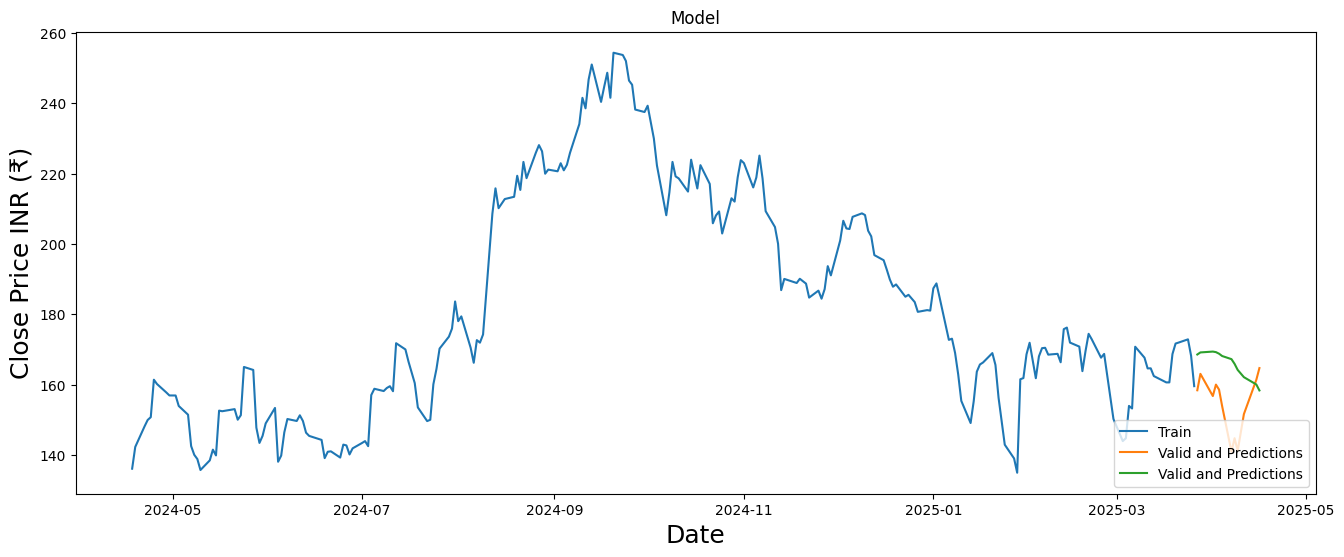

Price            Close Predictions
Ticker     INOXWIND.NS            
Date                              
2025-03-27  158.369995  168.542328
2025-03-28  163.039993  169.131165
2025-04-01  156.729996  169.371063
2025-04-02  159.979996  169.215317
2025-04-03  158.559998  168.769989


Price,Close,Predictions
Ticker,INOXWIND.NS,
Date,,
2025-03-27,158.369995,168.542328
2025-03-28,163.039993,169.131165
2025-04-01,156.729996,169.371063
2025-04-02,159.979996,169.215317
2025-04-03,158.559998,168.769989
2025-04-04,153.850006,168.110336
2025-04-07,140.880005,167.221924
2025-04-08,144.740005,165.885986


In [ ]:
print(f'RMSE: {rmse}')
plot_predictions(data, training_data_len, predictions)
#print(results_df.tail(10))

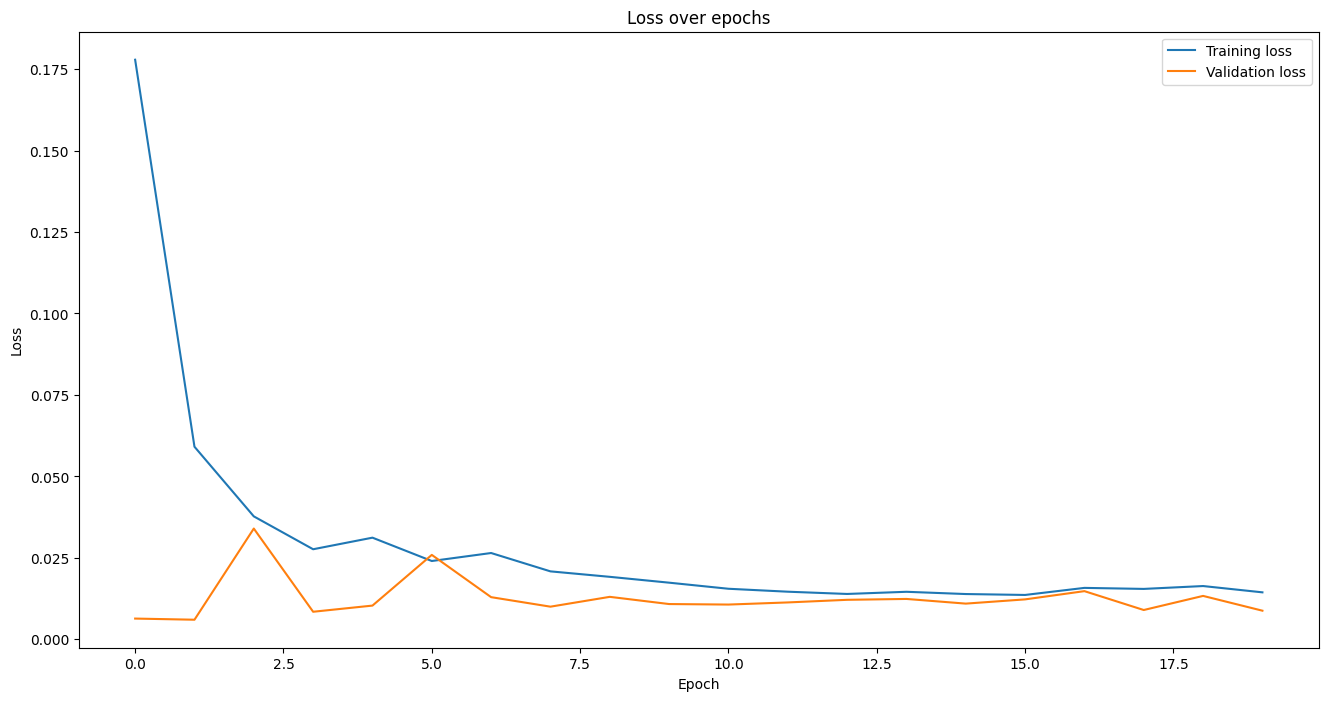

In [ ]:
plt.figure(figsize=(16,8))
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

### **LSTM-Based Analysis of TATAPOWER**

In [ ]:
df = yf.download('TATAPOWER.NS', start=start, end=end)
x_train, y_train, scaler, training_data_len, data, dataset = prepare_data_for_lstm2(df)

[*********************100%***********************]  1 of 1 completed


In [ ]:
model, history = build_and_train_lstm(x_train, y_train, epochs=20, batch_size=32)
predictions, rmse = evaluate_lstm(model, scaler, training_data_len, dataset)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 557ms/step - loss: 0.1915 - mse: 0.1915 - val_loss: 0.0073 - val_mse: 0.0073
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 651ms/step - loss: 0.0403 - mse: 0.0403 - val_loss: 0.0195 - val_mse: 0.0195
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 307ms/step - loss: 0.0312 - mse: 0.0312 - val_loss: 0.0125 - val_mse: 0.0125
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 437ms/step - loss: 0.0209 - mse: 0.0209 - val_loss: 0.0115 - val_mse: 0.0115
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 403ms/step - loss: 0.0179 - mse: 0.0179 - val_loss: 0.0146 - val_mse: 0.0146
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 416ms/step - loss: 0.0185 - mse: 0.0185 - val_loss: 0.0100 - val_mse: 0.0100
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 300ms/step - loss: 0.0170 - mse: 0.0170 - val_loss: 0.0088 - val_mse: 0.0088
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 309ms/step - loss: 0.0158 - mse: 0.0158 - val_loss: 0.0074 - val_mse: 0.0074
Epoch 9/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 310ms/step - loss: 0.0158 - mse: 

RMSE: 13.567030536942276


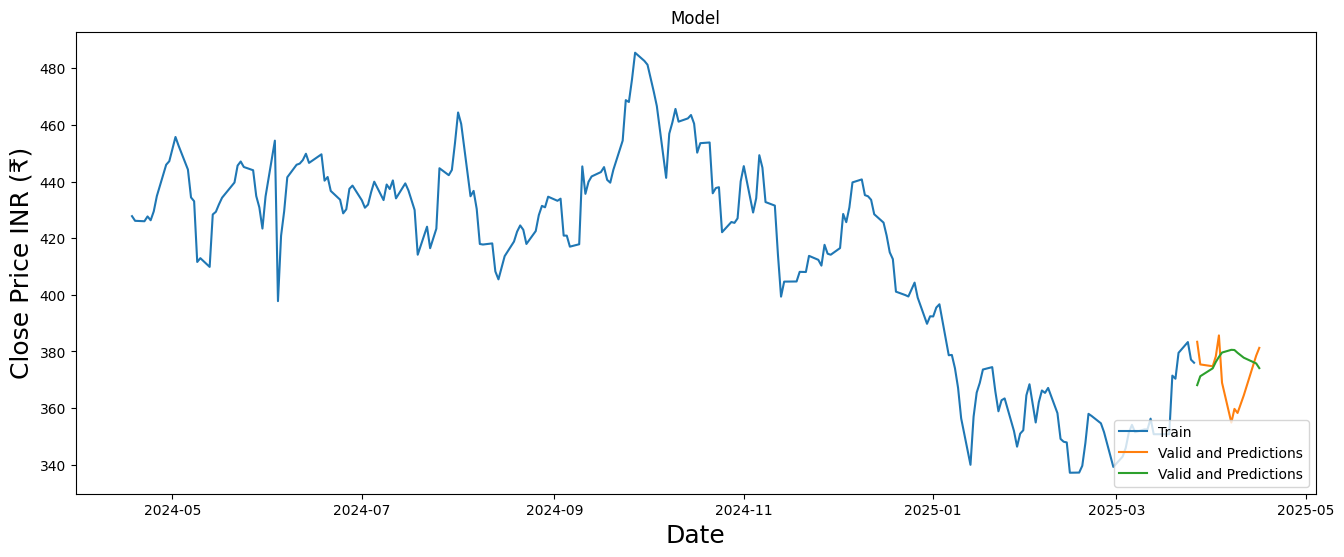

Price             Close Predictions
Ticker     TATAPOWER.NS            
Date                               
2025-03-27   383.399994  368.085144
2025-03-28   375.399994  371.232391
2025-04-01   374.750000  374.023163
2025-04-02   378.250000  376.281036
2025-04-03   385.649994  378.052246


Price,Close,Predictions
Ticker,TATAPOWER.NS,
Date,,
2025-03-27,383.399994,368.085144
2025-03-28,375.399994,371.232391
2025-04-01,374.750000,374.023163
2025-04-02,378.250000,376.281036
2025-04-03,385.649994,378.052246
2025-04-04,368.950012,379.594910
2025-04-07,354.850006,380.561462
2025-04-08,359.700012,380.492584


In [ ]:
print(f'RMSE: {rmse}')
plot_predictions(data, training_data_len, predictions)


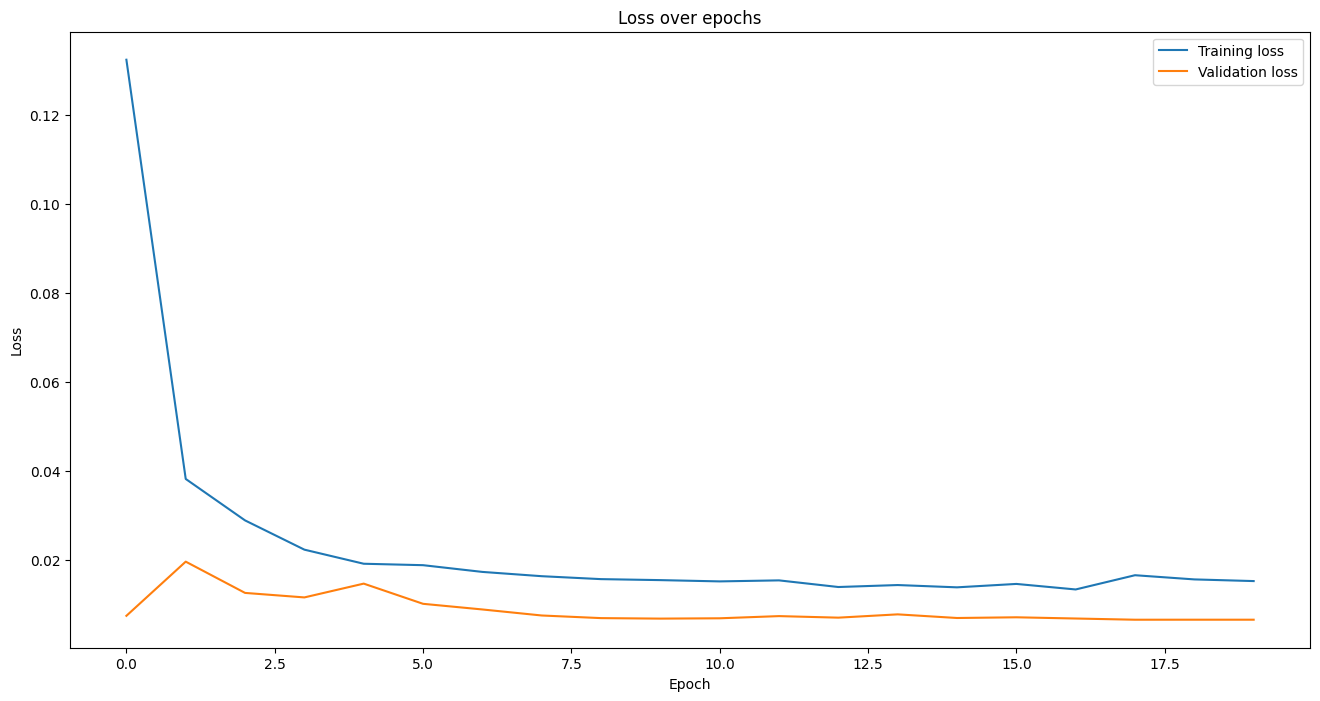

In [ ]:
plt.figure(figsize=(16,8))
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()